# VET Data

**Importing Package**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Sheets**

In [2]:
# Load Excel file
file_path = 'VET_Data_task1.xlsx'
xls = pd.ExcelFile(file_path)
print("Available Sheets:", xls.sheet_names)

Available Sheets: ['Tasks', 'Data Dictionary', 'Organisation', 'Contract', 'Student', 'Enrolment']


In [3]:
# Load individual sheets based on the Data Dictionary
organisation_df = pd.read_excel(xls, sheet_name='Organisation')
contract_df = pd.read_excel(xls, sheet_name='Contract')
student_df = pd.read_excel(xls, sheet_name='Student')
enrolment_df = pd.read_excel(xls, sheet_name='Enrolment')

In [4]:
# Display basic info and first few rows
display(organisation_df.head(10))

,Provider_ID,RTO_Code,RTO_Name,Organisation_Type,Region
0,P001,1001,Charles Darwin University,Public,Darwin
1,P002,1002,TAFE NT,Public,Darwin
2,P003,2001,NT Skills & Training Pty Ltd,Private,Alice Springs
3,P004,2002,Barkly Regional Training Services,Private,Tennant Creek
4,P005,2003,Top End Workforce Solutions,Private,Darwin
5,P006,3001,Arafura Learning Institute,Private,Katherine
6,P007,3002,Desert Training Co,Private,Alice Springs
7,P008,1003,Jabiru Community College,Public,Jabiru
8,P003,2001,NT Skills & Training,Private,Alice Springs
9,P001,1001,Charles Darwin University (Branch),Public,Darwin


**Data Cleaning**

In [5]:
# Convert all columns to lowercase
organisation_df.columns = organisation_df.columns.str.lower()

In [6]:
# Check unique providers and count of entries per provider ID
print("Unique Provider IDs:", organisation_df['provider_id'].nunique())
print("Total Rows:", len(organisation_df))

# View duplicate Provider IDs if any exist
duplicates = organisation_df[organisation_df.duplicated(subset=['provider_id'], keep=False)]
if not duplicates.empty:
    print("\nProviders with multiple entries/branches:")
    display(duplicates)

Unique Provider IDs: 8
Total Rows: 10

Providers with multiple entries/branches:


,provider_id,rto_code,rto_name,organisation_type,region
0,P001,1001,Charles Darwin University,Public,Darwin
2,P003,2001,NT Skills & Training Pty Ltd,Private,Alice Springs
8,P003,2001,NT Skills & Training,Private,Alice Springs
9,P001,1001,Charles Darwin University (Branch),Public,Darwin


In [7]:
# Remove duplicate provider IDs, keeping the first entry
organisation_df = organisation_df.drop_duplicates(subset=['provider_id'], keep='first')

# Verify the updated row count
print("Total Rows after removing duplicates:", len(organisation_df))

Total Rows after removing duplicates: 8


In [8]:
display(organisation_df)

,provider_id,rto_code,rto_name,organisation_type,region
0,P001,1001,Charles Darwin University,Public,Darwin
1,P002,1002,TAFE NT,Public,Darwin
2,P003,2001,NT Skills & Training Pty Ltd,Private,Alice Springs
3,P004,2002,Barkly Regional Training Services,Private,Tennant Creek
4,P005,2003,Top End Workforce Solutions,Private,Darwin
5,P006,3001,Arafura Learning Institute,Private,Katherine
6,P007,3002,Desert Training Co,Private,Alice Springs
7,P008,1003,Jabiru Community College,Public,Jabiru


**Exploratory Data Analysis (EDA)**

In [9]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [10]:
print(organisation_df.columns.tolist())

['provider_id', 'rto_code', 'rto_name', 'organisation_type', 'region']


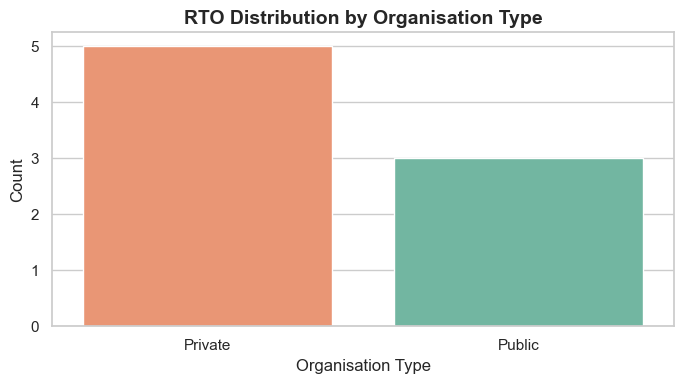

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=organisation_df, 
    x='organisation_type', 
    hue='organisation_type',  
    legend=False,          
    order=organisation_df['organisation_type'].value_counts().index, 
    palette='Set2'
)

plt.title('RTO Distribution by Organisation Type', fontsize=14, fontweight='bold')
plt.xlabel('Organisation Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

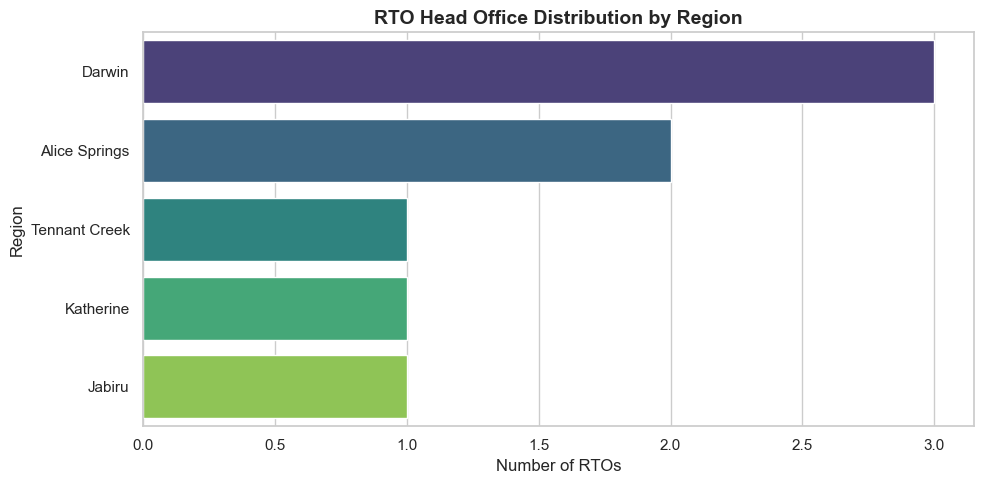

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=organisation_df, 
    y='region', 
    hue='region',       
    legend=False,       
    order=organisation_df['region'].value_counts().index, 
    palette='viridis'
)

plt.title('RTO Head Office Distribution by Region', fontsize=14, fontweight='bold')
plt.xlabel('Number of RTOs', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

region             Alice Springs  Darwin  Jabiru  Katherine  Tennant Creek
organisation_type                                                         
Private                        2       1       0          1              1
Public                         0       2       1          0              0


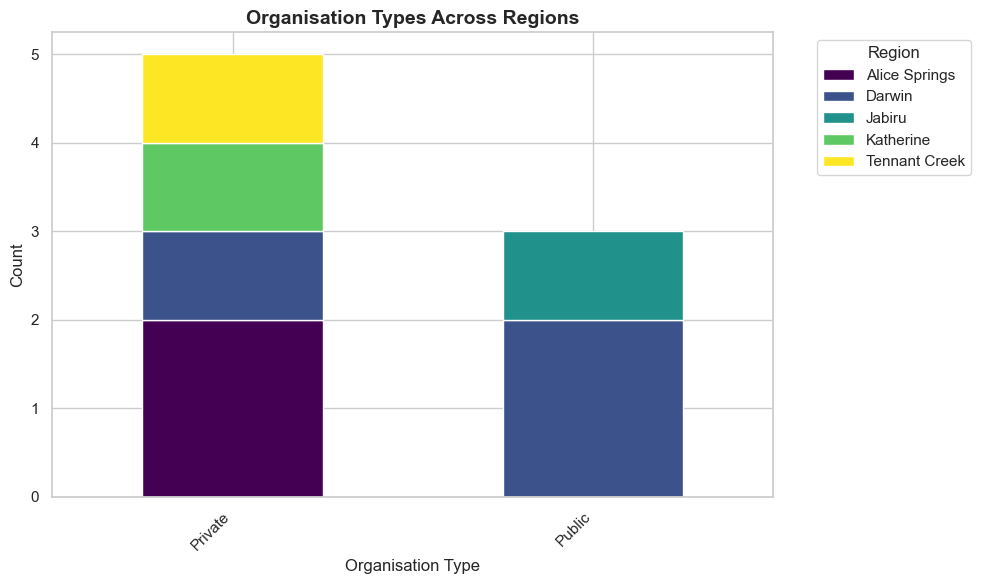

In [21]:
# Create a cross-tabulation of organisation type by region
cross_tab = pd.crosstab(organisation_df['organisation_type'], organisation_df['region'])
print(cross_tab)

# Plot as a stacked or grouped bar chart
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Organisation Types Across Regions', fontsize=14, fontweight='bold')
plt.xlabel('Organisation Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()